In [1]:
!pip install ultralytics -q
import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
from collections import Counter
from tqdm import tqdm
import torch

In [2]:
# фиксируем сид
SEED = 993
random.seed(SEED)
np.random.seed(SEED)
import torch
torch.manual_seed(SEED)

In [3]:
import zipfile


with zipfile.ZipFile('/content/2026-cv-competition (2).zip', 'r') as zip_ref:
    zip_ref.extractall('data')
TRAIN_IMG = 'data/train/train/images'
TRAIN_LABEL = 'data/train/train/labels'
TEST_IMG  = 'data/test/test/images'

In [4]:
def add_test_noise(image):
    # в тестовом файлу на изображениях много шума,поэтому будем обучать модель на трейне с добавлением шума
    h, w = image.shape[:2]
    img_copy = image.copy()
    if np.random.random() > 0.8:
        gray = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)
        img_copy = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    # точки
    noise = np.random.randint(0, 100, (h, w), dtype=np.uint8)
    salt = noise > 97
    pepper = noise < 2

    img_copy[salt] = 255
    img_copy[pepper] = 0

    #  Гауссовский шум
    gauss = np.random.normal(0, 12, (h, w, 3)).astype(np.uint8)
    img_copy = cv2.add(img_copy, gauss)
    # Пятна
    if np.random.random() < 0.5:
        num_blobs = np.random.randint(1, 4)
        for _ in range(num_blobs):
            cx = np.random.randint(-w//4, w + w//4)
            cy = np.random.randint(-h//4, h + h//4)
            r = np.random.randint(5, min(h, w)//6)
            alpha = np.random.uniform(0.15, 0.5)

            Y, X = np.ogrid[:h, :w]
            dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
            mask = np.exp(-(dist**2) / (2 * (r**2)))
            mask = np.clip(mask, 0, alpha)
            mask_3ch = mask[:, :, np.newaxis]

            if np.random.random() > 0.5:
                img_copy = (img_copy * (1 - mask_3ch)).astype(np.uint8)
            else:
                img_copy = (img_copy + 255 * mask_3ch).clip(0, 255).astype(np.uint8)
    #  JPEG артефакты
    if np.random.random() > 0.5:
        quality = np.random.randint(50, 85)
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
        _, encimg = cv2.imencode('.jpg', img_copy, encode_param)
        img_copy = cv2.imdecode(encimg, 1)

    return img_copy

def add_noise_to_training_set():
    train_images = sorted(os.listdir(TRAIN_IMG))

    for img_name in tqdm(train_images, desc="Adding noise to train"):
        img_path = os.path.join(TRAIN_IMG, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            if np.random.random() > 0.3:
                img_noisy = add_test_noise(img)
                cv2.imwrite(img_path, img_noisy)

In [5]:
class_counts = Counter()
total_boxes = 0

for label_file in os.listdir(TRAIN_LABEL):
    with open(f"{TRAIN_LABEL}/{label_file}") as f:
        for line in f:
            cls = int(line.split()[0])
            class_counts[cls] += 1
            total_boxes += 1

NUM_CLASSES = max(class_counts.keys()) + 1 if class_counts else 1

print(f"Всего изображений в train: {len(os.listdir(TRAIN_IMG))}")
print(f"Всего боксов в train: {total_boxes}")
print(f"Количество классов: {NUM_CLASSES}")
print(f"Распределение по классам (первые 10): {dict(list(class_counts.most_common(10)))}")

Всего изображений в train: 1697
Всего боксов в train: 10498
Количество классов: 52
Распределение по классам (первые 10): {50: 853, 51: 452, 26: 327, 32: 290, 34: 289, 40: 277, 29: 276, 39: 274, 10: 263, 13: 256}


In [6]:
sizes = []
for img_name in os.listdir(TRAIN_IMG)[:500]:
    img = cv2.imread(f"{TRAIN_IMG}/{img_name}")
    if img is not None:
        sizes.append(img.shape[:2])

sizes = np.array(sizes)
print(f"Средний размер изображений: {sizes.mean(axis=0).astype(int)}")
print(f"Медианный размер: {np.median(sizes, axis=0).astype(int)}")
print(f"Min размер: {sizes.min(axis=0)}")
print(f"Max размер: {sizes.max(axis=0)}")

Средний размер изображений: [640 640]
Медианный размер: [640 640]
Min размер: [640 640]
Max размер: [640 640]


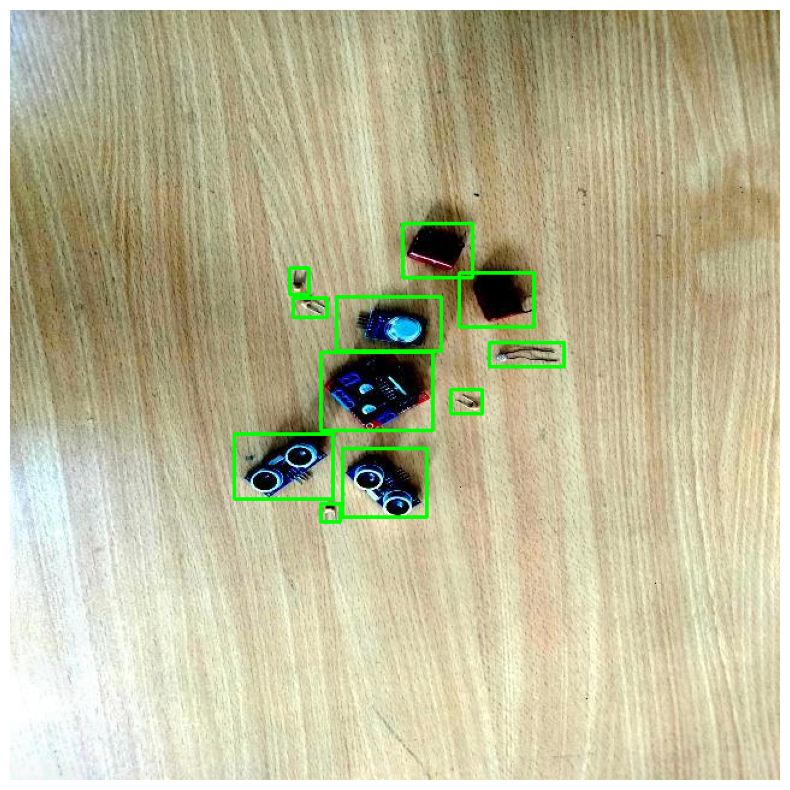

In [7]:
def show_sample(img_path, label_path):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:
        cls, xc, yc, bw, bh = map(float, line.split())
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.figure(figsize=(10, 10))
    plt.imshow(img[:, :, ::-1])
    plt.axis("off")
    plt.show()

sample_img = sorted(os.listdir(TRAIN_IMG))[0]
show_sample(f"{TRAIN_IMG}/{sample_img}",
            f"{TRAIN_LABEL}/{sample_img.replace('.jpg', '.txt')}")

In [8]:
add_noise_to_training_set()
images =sorted(os.listdir(TRAIN_IMG))
train_files, val_files = train_test_split(
    images,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

print(f"Train size: {len(train_files)}")
print(f"Val size: {len(val_files)}")
BASE_DIR = "yolo_data"
for split in ["train", "val"]:
    os.makedirs(f"{BASE_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{BASE_DIR}/labels/{split}", exist_ok=True)

for img in tqdm(train_files, desc="Copying train"):
    shutil.copy(f"{TRAIN_IMG}/{img}", f"{BASE_DIR}/images/train/{img}")
    label_file = img.replace('.jpg', '.txt')
    shutil.copy(f"{TRAIN_LABEL}/{label_file}", f"{BASE_DIR}/labels/train/{label_file}")

for img in tqdm(val_files, desc="Copying val"):
    shutil.copy(f"{TRAIN_IMG}/{img}", f"{BASE_DIR}/images/val/{img}")
    label_file = img.replace('.jpg', '.txt')
    shutil.copy(f"{TRAIN_LABEL}/{label_file}", f"{BASE_DIR}/labels/val/{label_file}")

yaml_text = f"""
path: {BASE_DIR}
train: images/train
val: images/val
nc: {NUM_CLASSES}
names: { {i: f"class_{i}" for i in range(NUM_CLASSES)} }
"""

with open(f"{BASE_DIR}/data.yaml", "w") as f:
    f.write(yaml_text)

print("data.yaml создан")

model = YOLO("yolov8s.pt")

results = model.train(
    data=f"{BASE_DIR}/data.yaml",
    epochs=60,
    imgsz=832,
    batch=16,
    seed=SEED,
    verbose=True,
    patience=30,
    save=True,
    lr0=0.001,
    cos_lr=True,
    mosaic=0.2,
    mixup=0.0,
    copy_paste=0.0,
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.4,
    erasing=0.3,
    fliplr=0.5,
    translate=0.2,
    scale=0.3,
    project="runs/train",
    name="yolov8s_cv",
    device=0
)

metrics = model.val()
print(f"\nРезультаты валидации:")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP75: {metrics.box.map75:.4f}")

Adding noise to train: 100%|██████████| 1697/1697 [01:28<00:00, 19.12it/s]


Train size: 1357
Val size: 340


Copying val: 100%|██████████| 340/340 [00:00<00:00, 597.65it/s]


data.yaml создан
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=yolo_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.3, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=832, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.2, multi_scale=0.0, name=yolov8s_cv, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

In [10]:

!pip install ensemble-boxes -q

import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from ultralytics import YOLO
from ensemble_boxes import weighted_boxes_fusion
import torch
from google.colab import files

SAMPLE_SUB_PATH = 'data/sample_submission.csv'
TEST_IMG = 'data/test/test/images'
best_model_path = "runs/detect/runs/train/yolov8s_cv/weights/best.pt"

model = YOLO(best_model_path)
configs = [
    {'name': 's640_c012_iou055', 'conf': 0.12, 'iou': 0.55, 'imgsz': 640, 'augment': False},
    {'name': 's640_c016_iou060', 'conf': 0.16, 'iou': 0.65, 'imgsz': 640, 'augment': False},
    {'name': 's896_c012_iou055', 'conf': 0.12, 'iou': 0.55, 'imgsz': 896, 'augment': False},
    {'name': 's896_c016_iou060', 'conf': 0.16, 'iou': 0.60, 'imgsz': 896, 'augment': False},
    {'name': 's1152_c012_iou055', 'conf': 0.12, 'iou': 0.55, 'imgsz': 1152, 'augment': False},
    {'name': 's1152_c016_iou060', 'conf': 0.16, 'iou': 0.60, 'imgsz': 1152, 'augment': False},

    {'name': 's1152_c014_iou055_tta', 'conf': 0.14, 'iou': 0.55, 'imgsz': 1152, 'augment': True},
    {'name': 's1152_c014_iou060_tta', 'conf': 0.14, 'iou': 0.60, 'imgsz': 1152, 'augment': True},
    {'name': 's1024_c015_iou055_tta', 'conf': 0.15, 'iou': 0.55, 'imgsz': 1024, 'augment': True},
    {'name': 's1024_c015_iou060_tta', 'conf': 0.15, 'iou': 0.60, 'imgsz': 1024, 'augment': True},
]

print("Запуск предсказаний...")
print("="*50)

all_predictions = []

for cfg_idx, cfg in enumerate(tqdm(configs, desc="Predictions")):
    preds = model.predict(
        TEST_IMG,
        imgsz=cfg['imgsz'],
        conf=cfg['conf'],
        iou=cfg['iou'],
        augment=cfg['augment'],
        device=0,
        seed=SEED,
        verbose=False
    )
    all_predictions.append(preds)

preds_dict = {}
n_images = len(all_predictions[0])

for img_idx in tqdm(range(n_images), desc="WBF processing"):
    img_path = all_predictions[0][img_idx].path
    image_id = os.path.basename(img_path).replace('.jpg', '')
    h, w = all_predictions[0][img_idx].orig_shape

    boxes_list = []
    scores_list = []
    labels_list = []

    for preds in all_predictions:
        boxes = []
        scores = []
        labels = []
        result = preds[img_idx]

        if result.boxes is not None:
            for box in result.boxes:
                cls = int(box.cls[0].item())
                conf = float(box.conf[0].item())
                x1, y1, x2, y2 = box.xyxy[0].tolist()

                boxes.append([x1/w, y1/h, x2/w, y2/h])
                scores.append(conf)
                labels.append(cls)

        boxes_list.append(boxes)
        scores_list.append(scores)
        labels_list.append(labels)

    if sum(len(b) for b in boxes_list) > 0:
        boxes, scores, labels = weighted_boxes_fusion(
            boxes_list, scores_list, labels_list,

            iou_thr=0.55,
            skip_box_thr=0.01
        )
    else:
        boxes, scores, labels = [], [], []
    parts = []
    for b, s, l in zip(boxes, scores, labels):
        x1 = int(b[0] * w)
        y1 = int(b[1] * h)
        x2 = int(b[2] * w)
        y2 = int(b[3] * h)

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(w, x2)
        y2 = min(h, y2)

        if (x2 - x1) >= 5 and (y2 - y1) >= 5:
            parts.extend([str(l), f"{s:.6f}", str(x1), str(y1), str(x2), str(y2)])

    preds_dict[image_id] = " ".join(parts) if parts else " "

total_boxes = sum(len(p.split()) // 6 for p in preds_dict.values() if p != " ")


print("\nПроверка формата сабмишна...")
for image_id, pred in list(preds_dict.items())[:3]:
    if pred != " ":
        tokens = pred.split()
        print(f"  {image_id}: {len(tokens)} токенов = {len(tokens)//6} боксов")
        if len(tokens) % 6 != 0:
            print(f"    ОШИБКА: {len(tokens)} не делится на 6!")
    else:
        print(f"  {image_id}: пусто")

print("\nСохранение сабмишна...")

sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
output_path = "submission_10_configs.csv"

with open(output_path, "w", newline="", encoding="utf-8") as f:
    f.write("image_id,PredictionString\n")
    for image_id in sample_sub['image_id']:
        pred = preds_dict.get(image_id, " ")
        if pred == " ":
            f.write(f'{image_id},{pred}\n')
        else:
            f.write(f'{image_id},"{pred}"\n')

df_check = pd.read_csv(output_path)

sample_row = df_check[df_check['PredictionString'] != ' '].iloc[0] if len(df_check[df_check['PredictionString'] != ' ']) > 0 else None
if sample_row is not None:
    tokens = str(sample_row['PredictionString']).split()
    print(f"  Пример: {sample_row['image_id']}")
    print(f"  Токены: {tokens[:12]}...")
    print(f"  Количество токенов: {len(tokens)} (должно делиться на 6)")

files.download(output_path)
print(f"\nФайл {output_path} скачан!")

Запуск предсказаний...


WBF processing: 100%|██████████| 424/424 [00:02<00:00, 143.51it/s]



Проверка формата сабмишна...
  IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1ac5492b4c81c: 204 токенов = 34 боксов
  IMG20240228122949_jpg.rf.f763b523e7bb4e72507961519cbbef88: 48 токенов = 8 боксов
  IMG20240228122955_jpg.rf.18d6c6ad9c8c69153da34c4074004853: 102 токенов = 17 боксов

Сохранение сабмишна...
  Пример: IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1ac5492b4c81c
  Токены: ['28.0', '0.900159', '174', '539', '271', '610', '16.0', '0.759526', '273', '280', '344', '339']...
  Количество токенов: 204 (должно делиться на 6)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Файл submission_10_configs.csv скачан!
